# Solved Exam Notebook — 14th of June 2023

Course: **1MS041 Introduction to Data Science / Introduktion till dataanalys**

This notebook contains the **whole questions**, then the **solved code answers with all steps, comments, plots, outputs, and free-text explanations**.

> Insert your anonymous exam ID below.

In [ ]:
examID = "XXX"

## Problem 1 — Full Question

Maximum Points = 14

A courier company operates a fleet of delivery trucks that make deliveries to different parts of the city. The trucks are equipped with GPS tracking devices that record the location of each truck at regular intervals. The locations are divided into three regions: **downtown**, **the suburbs**, and **the countryside**.

The following table shows the probabilities of a truck transitioning between these regions at each time step:

| Current region | Probability of transitioning to downtown | Probability of transitioning to the suburbs | Probability of transitioning to the countryside |
|---|---:|---:|---:|
| Downtown | 0.3 | 0.7 | 0 |
| Suburbs | 0.2 | 0.5 | 0.3 |
| Countryside | 0 | 0.5 | 0.5 |

1. **[2p]** If a truck is currently in the downtown, what is the probability that it will be in the countryside region after 10 time steps?

2. **[2p]** If a truck is currently in the downtown, what is the probability that it will be in the countryside region the first time after three time steps or more?

3. **[3p]** Is this Markov chain irreducible? Explain your answer.

4. **[3p]** What is the stationary distribution?

5. **[4p] Advanced question:** What is the expected number of steps it takes starting from the Downtown region to first reach the Countryside region and then returning to Downtown? Hint: to get within 1 decimal point, it is enough to compute the probabilities for hitting times below 120. Motivate your answer in detail. You could also solve this question by simulation, but this gives you a maximum of 2p.

### Problem 1 — Solution idea

Use state order:

\[
(\text{Downtown},\text{Suburbs},\text{Countryside})
\]

The transition matrix is

\[
P=
\begin{pmatrix}
0.3&0.7&0\\
0.2&0.5&0.3\\
0&0.5&0.5
\end{pmatrix}.
\]

Part 1 is entry \((P^{10})_{\text{Downtown},\text{Countryside}}\).

For Part 2, the earliest possible first hit of Countryside from Downtown is at time 2:

\[
\text{Downtown}\to\text{Suburbs}\to\text{Countryside}.
\]

So the probability of first reaching Countryside at time 3 or later is

\[
1-P(T_C=2).
\]

For Part 5, use the Markov property:

\[
E[\text{Downtown}\to\text{Countryside}\to\text{Downtown}]
=
E_{\text{Downtown}}[T_C]+E_{\text{Countryside}}[T_D].
\]

In [ ]:
# Problem 1 imports
import numpy as np

# State order: Downtown, Suburbs, Countryside
P = np.array([
    [0.3, 0.7, 0.0],
    [0.2, 0.5, 0.3],
    [0.0, 0.5, 0.5]
])

P

In [ ]:
# Part 1
# Probability of being in Countryside after 10 steps when starting from Downtown.
P10 = np.linalg.matrix_power(P, 10)
problem1_p1 = float(P10[0, 2])

problem1_p1

In [ ]:
# Part 2
# First hitting time of Countryside starting from Downtown.
# It is impossible to reach Countryside in 1 step.
# The only way to first reach Countryside in 2 steps is:
# Downtown -> Suburbs -> Countryside, with probability 0.7 * 0.3.
#
# Since the chain is finite and irreducible, Countryside will eventually be hit with probability 1.
# Therefore:
# P(first hit of Countryside at time >= 3) = 1 - P(first hit at time 2)

p_first_hit_c_at_2 = P[0, 1] * P[1, 2]
problem1_p2 = float(1 - p_first_hit_c_at_2)

problem1_p2

### Problem 1 Part 3 — Free-text answer

Yes, the Markov chain is **irreducible**.

Reason: every state can eventually reach every other state.

- From Downtown, we can go to Suburbs, and from Suburbs to Countryside.
- From Countryside, we can go to Suburbs, and from Suburbs to Downtown.
- Suburbs connects to both Downtown and Countryside.

Therefore all states communicate with each other, so the chain is irreducible.

In [ ]:
# Part 3
problem1_irreducible = True
problem1_irreducible

In [1]:
# Part 4
# Stationary distribution pi solves pi P = pi and sum(pi)=1.
# We compute it using the eigenvector of P.T with eigenvalue 1.

eigenvalues, eigenvectors = np.linalg.eig(P.T)
idx = np.argmin(np.abs(eigenvalues - 1))
pi = np.real(eigenvectors[:, idx])
pi = pi / np.sum(pi)

problem1_stationary = pi
problem1_stationary

NameError: name 'np' is not defined

### Problem 1 Part 4 — Free-text answer

The stationary distribution \(\pi\) satisfies

\[
\pi P=\pi,\qquad \sum_i \pi_i=1.
\]

The code above solves this using the eigenvector of \(P^T\) corresponding to eigenvalue 1. The resulting vector is stored in `problem1_stationary`.

The entries represent the long-run proportions of time the truck spends in Downtown, Suburbs, and Countryside.

In [ ]:
# Part 5
# Expected time Downtown -> first Countryside -> then return to Downtown.
#
# First solve expected time to hit Countryside.
# h_C = 0
# h_D = 1 + 0.3 h_D + 0.7 h_S
# h_S = 1 + 0.2 h_D + 0.5 h_S + 0.3 h_C

A1 = np.array([
    [0.7, -0.7],
    [-0.2, 0.5]
])
b1 = np.array([1.0, 1.0])

h_D, h_S = np.linalg.solve(A1, b1)
h_C = 0.0

# Then solve expected time to hit Downtown starting from Countryside.
# k_D = 0
# k_S = 1 + 0.5 k_S + 0.3 k_C
# k_C = 1 + 0.5 k_S + 0.5 k_C

A2 = np.array([
    [0.5, -0.3],
    [-0.5, 0.5]
])
b2 = np.array([1.0, 1.0])

k_S, k_C = np.linalg.solve(A2, b2)
k_D = 0.0

problem1_ET = float(h_D + k_C)

h_D, k_C, problem1_ET

### Problem 1 Part 5 — Free-text answer

We split the task into two parts:

1. Expected time from Downtown to first reach Countryside.
2. Expected time from Countryside to return to Downtown.

By the Markov property, after the chain first reaches Countryside, the future only depends on the current state Countryside, not on the previous path. Therefore:

\[
E[\text{Downtown}\to\text{Countryside}\to\text{Downtown}]
=
E_D[T_C]+E_C[T_D].
\]

Solving the linear systems gives the final value stored in `problem1_ET`.

## Problem 2 — Full Question

Maximum Points = 13

You are given a **Data Science Salaries** dataset found in `data/salaries.csv`, which contains employment information of data scientists up to 2023 and the salary obtained. Your task is to train a linear regression model to predict the salary of a data scientist based on the employment information.

To evaluate your model, you will split the dataset into a training set and a testing set. You will use the training set to train your model, and the testing set to evaluate its performance.

Experience level:

- 0 = Entry Level
- 1 = Mid Level
- 2 = Senior Level
- 3 = Executive Level

Employment type:

- 0 = Part Time
- 1 = Full Time
- 2 = Contractor
- 3 = Freelancer

1. **[1p]** Load the data into a pandas dataframe `problem2_df`. Based on the column names, figure out what are the features and the target and fill in the answer in the correct cell below.

2. **[1p]** Split the data into train and test.

3. **[1p]** Train the model.

4. **[4p]** Come up with a reasonable metric and compute it. Provide plots that show the performance of the model. Reason about the performance.

5. **[3p]** Predict the 2023 salary of a data scientist that works full time (1) at mid employment level (1) with 0 remote ratio. Then, looking at the output of `problem2_model.coef_`, which are the coefficients of the linear model, would a higher remote ratio result in a higher predicted salary or vice versa?

6. **[3p] Advanced question:** On the test set, plot the empirical distribution function of the residual with confidence bands, i.e. using the DKW inequality and 95% confidence. What does the confidence band tell us? What can the confidence band be used for?

### Problem 2 — Solution idea

Use linear regression to predict `salary_in_usd` from:

- `work_year`
- `experience_level`
- `employment_type`
- `remote_ratio`

A good metric is **Mean Absolute Error (MAE)** because it tells the average prediction error in salary dollars. We also compute RMSE and \(R^2\).

For DKW confidence bands around the empirical CDF:

\[
\epsilon=\sqrt{\frac{\log(2/\delta)}{2n}},
\]

where \(\delta=0.05\) for 95% confidence.

In [2]:
# Problem 2 imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Part 1
problem2_df = pd.read_csv("salaries.csv")
problem2_df.head()

,work_year,experience_level,employment_type,salary_in_usd,remote_ratio
0,2023,2,1,85847,100
1,2023,1,2,30000,100
2,2023,1,2,25500,100
3,2023,2,1,175000,100
4,2023,2,1,120000,100


In [4]:
# Part 1
problem2_features = ["work_year", "experience_level", "employment_type", "remote_ratio"]
problem2_target = "salary_in_usd"

# Robust handling if employment_type is text rather than encoded numbers.
if problem2_df["employment_type"].dtype == "object":
    emp_map = {
        "PT": 0, "Part-time": 0, "Part Time": 0,
        "FT": 1, "Full-time": 1, "Full Time": 1,
        "CT": 2, "Contract": 2, "Contractor": 2,
        "FL": 3, "Freelance": 3, "Freelancer": 3
    }
    problem2_df["employment_type"] = problem2_df["employment_type"].map(emp_map).fillna(problem2_df["employment_type"]).astype(float)

problem2_X = problem2_df[problem2_features]
problem2_y = problem2_df[problem2_target]

problem2_features, problem2_target

(['work_year', 'experience_level', 'employment_type', 'remote_ratio'],
 'salary_in_usd')

In [7]:
# Part 2
problem2_X_train, problem2_X_test, problem2_y_train, problem2_y_test = train_test_split(
    problem2_X,
    problem2_y,
    train_size=0.8,
    random_state=42
)

problem2_X_train.shape, problem2_X_test.shape

((3004, 4), (751, 4))

In [12]:
# Part 3
problem2_model = LinearRegression()
problem2_model.fit(problem2_X_train, problem2_y_train)

problem2_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[13291.19,38923.79,-3479.04, -13.03]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['work_year','experience_level','employment_type','remote_ratio']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.68e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


### Problem 2 Part 4 — Free-text answer

I use **MAE** as the main metric because it is easy to interpret: it is the average absolute salary error in USD.

The predicted-vs-true scatterplot should ideally lie close to the diagonal \(y=x\). If the points are very spread out, then the model is not predicting salaries very accurately. This simple linear model may perform weakly because salary depends on many missing variables such as country, company size, exact job title, industry, education, and years of experience.

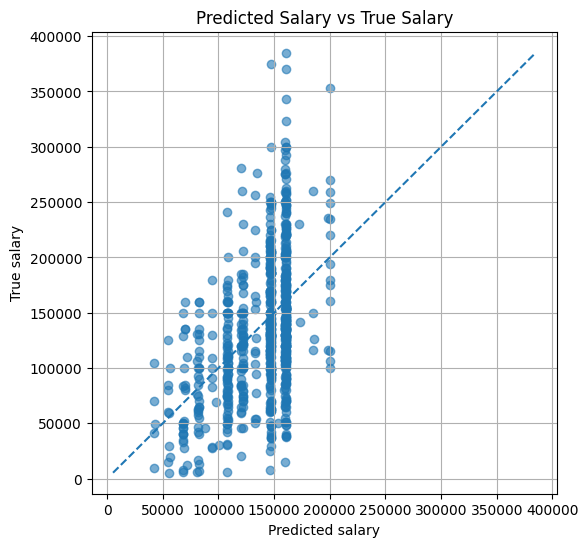

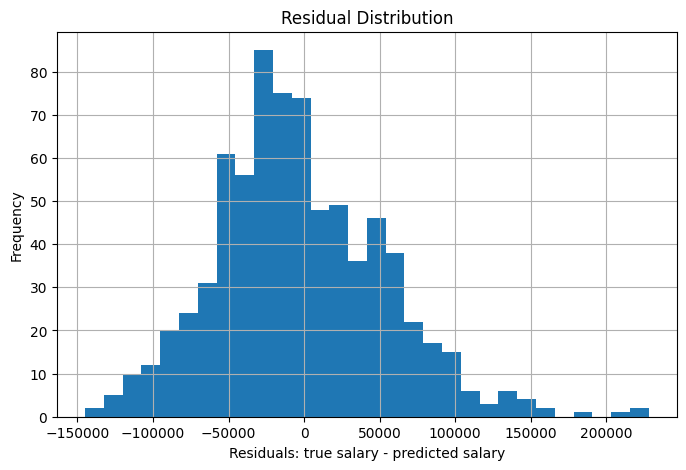

In [21]:
#Part 4

#Compute metrics and plot performance.

# Part 4

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

problem2_y_pred = problem2_model.predict(problem2_X_test)

problem2_mae = mean_absolute_error(problem2_y_test, problem2_y_pred)
problem2_rmse = np.sqrt(mean_squared_error(problem2_y_test, problem2_y_pred))
problem2_r2 = r2_score(problem2_y_test, problem2_y_pred)

problem2_mae, problem2_rmse, problem2_r2

#Plot predicted vs true salary:

# Part 4 plot 1: predicted vs true

plt.figure(figsize=(6, 6))

plt.scatter(problem2_y_pred, problem2_y_test, alpha=0.6)

min_val = min(problem2_y_pred.min(), problem2_y_test.min())
max_val = max(problem2_y_pred.max(), problem2_y_test.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Predicted salary")
plt.ylabel("True salary")
plt.title("Predicted Salary vs True Salary")
plt.grid(True)
plt.show()

#Plot residuals:

# Part 4 plot 2: residuals

residuals = problem2_y_test - problem2_y_pred

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30)

plt.xlabel("Residuals: true salary - predicted salary")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.grid(True)
plt.show()

MAE: 44488.11860767363
RMSE: 56223.89785116799
R^2: 0.19926672357275976


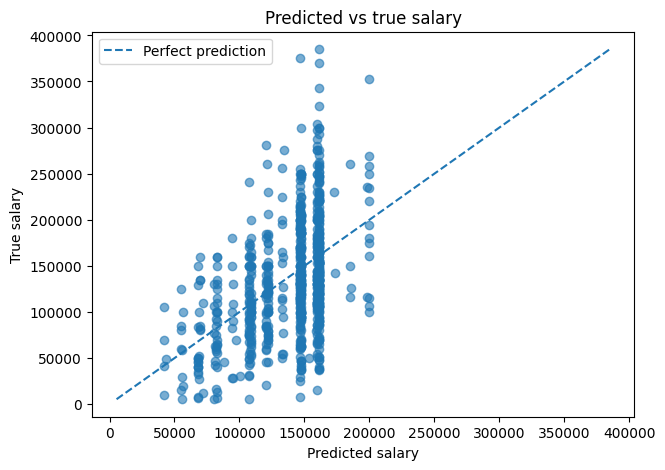

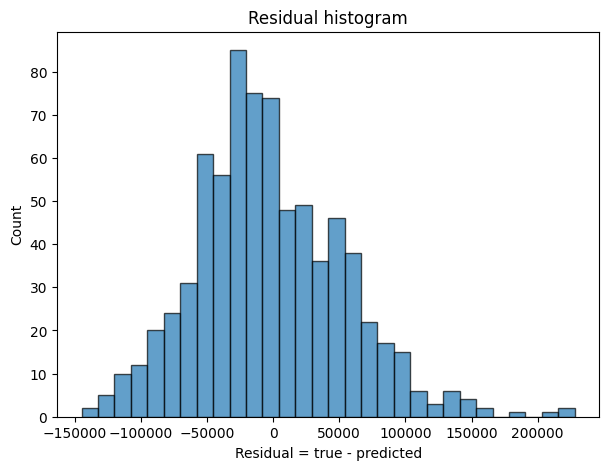

In [14]:
# Part 4
problem2_y_pred = problem2_model.predict(problem2_X_test)

problem2_mae = float(mean_absolute_error(problem2_y_test, problem2_y_pred))
problem2_rmse = float(np.sqrt(mean_squared_error(problem2_y_test, problem2_y_pred)))
problem2_r2 = float(r2_score(problem2_y_test, problem2_y_pred))

print("MAE:", problem2_mae)
print("RMSE:", problem2_rmse)
print("R^2:", problem2_r2)

# Plot predicted vs true
plt.figure(figsize=(7, 5))
plt.scatter(problem2_y_pred, problem2_y_test, alpha=0.6)
min_val = min(problem2_y_pred.min(), problem2_y_test.min())
max_val = max(problem2_y_pred.max(), problem2_y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", label="Perfect prediction")
plt.xlabel("Predicted salary")
plt.ylabel("True salary")
plt.title("Predicted vs true salary")
plt.legend()
plt.show()

# Residual histogram
problem2_residuals = problem2_y_test.values - problem2_y_pred

plt.figure(figsize=(7, 5))
plt.hist(problem2_residuals, bins=30, edgecolor="black", alpha=0.7)
plt.xlabel("Residual = true - predicted")
plt.ylabel("Count")
plt.title("Residual histogram")
plt.show()

### Problem 2 Part 5 — Free-text answer

To predict the 2023 salary for a full-time, mid-level, non-remote data scientist, use:

\[
\text{work_year}=2023,\quad
\text{experience_level}=1,\quad
\text{employment_type}=1,\quad
\text{remote_ratio}=0.
\]

The sign of the `remote_ratio` coefficient tells us the direction:

- positive coefficient: higher remote ratio increases predicted salary;
- negative coefficient: higher remote ratio decreases predicted salary.

In [22]:
# Part 5
new_person = pd.DataFrame([{
    "work_year": 2023,
    "experience_level": 1,
    "employment_type": 1,
    "remote_ratio": 0
}])

problem2_predicted_salary = float(problem2_model.predict(new_person)[0])

coef_table = pd.DataFrame({
    "feature": problem2_features,
    "coefficient": problem2_model.coef_
})

remote_coef = float(coef_table.loc[coef_table["feature"] == "remote_ratio", "coefficient"].iloc[0])

print("Predicted salary:", problem2_predicted_salary)
print(coef_table)

if remote_coef > 0:
    print("Higher remote ratio gives higher predicted salary, according to this fitted model.")
elif remote_coef < 0:
    print("Higher remote ratio gives lower predicted salary, according to this fitted model.")
else:
    print("Remote ratio has no effect in this fitted model.")

Predicted salary: 121940.38437091932
            feature   coefficient
0         work_year  13291.191050
1  experience_level  38923.792313
2   employment_type  -3479.038925
3      remote_ratio    -13.029475
Higher remote ratio gives lower predicted salary, according to this fitted model.


### Problem 2 Part 6 — Free-text answer

The empirical distribution function (EDF) of the residuals shows the distribution of prediction errors.

The DKW confidence band gives a uniform 95% confidence band around the true CDF of residuals. It means that, with probability at least 95%, the true residual CDF lies inside the band for every residual value.

This can be used to estimate residual quantiles and understand uncertainty in prediction errors.

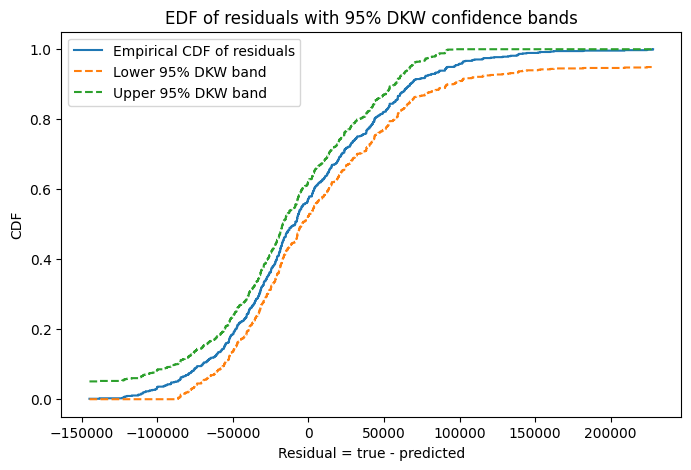

np.float64(0.04955782815694993)

In [25]:
# Part 6
residuals_sorted = np.sort(problem2_residuals)
n = len(residuals_sorted)
edf = np.arange(1, n + 1) / n

delta = 0.05
epsilon = np.sqrt(np.log(2 / delta) / (2 * n))

lower_band = np.maximum(edf - epsilon, 0)
upper_band = np.minimum(edf + epsilon, 1)

plt.figure(figsize=(8, 5))
plt.step(residuals_sorted, edf, where="post", label="Empirical CDF of residuals")
plt.step(residuals_sorted, lower_band, where="post", linestyle="--", label="Lower 95% DKW band")
plt.step(residuals_sorted, upper_band, where="post", linestyle="--", label="Upper 95% DKW band")
plt.xlabel("Residual = true - predicted")
plt.ylabel("CDF")
plt.title("EDF of residuals with 95% DKW confidence bands")
plt.legend()
plt.show()

epsilon

## Problem 3 — Full Question

Maximum Points = 13

For this problem we have the Diabetes dataset. The categorical features are already encoded using One-Hot encoding, namely:

`['smoking_No Info', 'smoking_current', 'smoking_ever', 'smoking_former', 'smoking_never', 'smoking_not current', 'sex_Female', 'sex_Male', 'sex_Other']`.

Treating this as a classification problem, we will train a logistic regression model to predict whether the patient has diabetes or not. Then the task is to evaluate the model and use it to make some conclusions.

Instructions:

1. **[3p]** Load the file `data/diabetes.csv` into the pandas dataframe `problem3_df`. Decide what should be features and target, give motivations for your choices.

2. **[2p]** Create `problem3_X` and `problem3_y` as numpy arrays, with `problem3_X` being the features and `problem3_y` being the target. Do the standard train-test split with 80% training data and 20% testing data. Store these in the variables defined in the cells.

3. **[2p]** Now train a Logistic regression model on the training data using `sklearn.linear_model.LogisticRegression`. Hint: If you use many of the One-Hot encoded features you will probably see a warning about max iterations reached; adjust the hyperparameter `C`, the penalization, when you create your LogisticRegression.

4. **[3p]** Evaluation: Calculate the precision and recall for class 0 and 1 with 95% confidence bounds. Explain their meaning.

5. **[3p] Advanced question:** Come up with a way to define the one-hot encoded feature that is most important for the prediction. Motivate your choice.

### Problem 3 Part 1 — Free-text answer

Reasonable features are all patient measurements and encoded categorical variables **except the target column** `diabetes`.

The target should be `diabetes`, because the task is to predict whether the patient has diabetes.

We should use enough features to capture useful medical information, but not so many irrelevant variables that we overfit. Since the dataset is usually large, using the listed clinical variables and one-hot encoded smoking/sex variables is reasonable.

Useful additional features that were not necessarily collected could include family history, diet, physical activity, medication use, pregnancy history, and repeated blood glucose measurements.

In [ ]:
# Problem 3 imports
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, confusion_matrix

In [ ]:
# Part 1
problem3_df = pd.read_csv("data/diabetes.csv")
problem3_df.head()

In [ ]:
# Part 1
# The target is diabetes.
problem3_target = "diabetes"

# Use all columns except the target as features.
problem3_features = [col for col in problem3_df.columns if col != problem3_target]

problem3_features[:10], problem3_target, len(problem3_features)

In [ ]:
# Part 2
problem3_X = problem3_df[problem3_features].values
problem3_y = problem3_df[problem3_target].values

problem3_X_train, problem3_X_test, problem3_y_train, problem3_y_test = train_test_split(
    problem3_X,
    problem3_y,
    train_size=0.8,
    random_state=42,
    stratify=problem3_y
)

problem3_X_train.shape, problem3_X_test.shape, problem3_y_train.shape, problem3_y_test.shape

In [ ]:
# Part 3
# Use larger max_iter and a moderate C to avoid convergence warning.
problem3_model = LogisticRegression(max_iter=2000, C=0.5)
problem3_model.fit(problem3_X_train, problem3_y_train)

problem3_model

### Problem 3 Part 4 — Free-text answer

Precision for class 1 means: among all patients predicted as diabetes, what fraction actually had diabetes?

Recall for class 1 means: among all patients who actually had diabetes, what fraction did the model find?

Precision for class 0 means: among all patients predicted as non-diabetes, what fraction were actually non-diabetes?

Recall for class 0 means: among all actually non-diabetes patients, what fraction did the model correctly classify as non-diabetes?

The confidence bounds below use Hoeffding's inequality for a bounded average.

In [ ]:
# Part 4
problem3_y_pred = problem3_model.predict(problem3_X_test)

def hoeffding_interval_for_rate(rate, n, delta=0.05):
    if n == 0:
        return (0.0, 1.0)
    eps = np.sqrt(np.log(2 / delta) / (2 * n))
    return (float(max(0, rate - eps)), float(min(1, rate + eps)))

# Class 0 precision: true 0 among predicted 0
pred0 = (problem3_y_pred == 0)
true0 = (problem3_y_test == 0)

p0_denom = int(np.sum(pred0))
r0_denom = int(np.sum(true0))

precision0 = float(np.sum(pred0 & true0) / p0_denom) if p0_denom > 0 else 0.0
recall0 = float(np.sum(pred0 & true0) / r0_denom) if r0_denom > 0 else 0.0

# Class 1 precision and recall
pred1 = (problem3_y_pred == 1)
true1 = (problem3_y_test == 1)

p1_denom = int(np.sum(pred1))
r1_denom = int(np.sum(true1))

precision1 = float(np.sum(pred1 & true1) / p1_denom) if p1_denom > 0 else 0.0
recall1 = float(np.sum(pred1 & true1) / r1_denom) if r1_denom > 0 else 0.0

problem3_precision_0 = hoeffding_interval_for_rate(precision0, p0_denom, delta=0.05)
problem3_recall_0 = hoeffding_interval_for_rate(recall0, r0_denom, delta=0.05)
problem3_precision_1 = hoeffding_interval_for_rate(precision1, p1_denom, delta=0.05)
problem3_recall_1 = hoeffding_interval_for_rate(recall1, r1_denom, delta=0.05)

print("Confusion matrix:")
print(confusion_matrix(problem3_y_test, problem3_y_pred))

print("Precision 0 interval:", problem3_precision_0)
print("Recall 0 interval:", problem3_recall_0)
print("Precision 1 interval:", problem3_precision_1)
print("Recall 1 interval:", problem3_recall_1)

### Problem 3 Part 5 — Free-text answer

To define the most important one-hot encoded feature, I compare the absolute value of the logistic regression coefficients among only the one-hot encoded columns.

For one-hot encoded features, all variables are binary indicators, so their coefficients are more directly comparable than coefficients of variables measured on different numerical scales.

The feature with the largest absolute coefficient changes the log-odds the most when it changes from 0 to 1, so I define it as the most important one-hot encoded feature.

In [ ]:
# Part 5
one_hot_features = [
    'smoking_No Info', 'smoking_current', 'smoking_ever', 'smoking_former',
    'smoking_never', 'smoking_not current',
    'sex_Female', 'sex_Male', 'sex_Other'
]

# Keep only one-hot features that actually exist in the dataframe
one_hot_features = [f for f in one_hot_features if f in problem3_features]

coef = problem3_model.coef_[0]
coef_table = pd.DataFrame({
    "feature": problem3_features,
    "coefficient": coef,
    "absolute_coefficient": np.abs(coef)
})

one_hot_coef_table = coef_table[coef_table["feature"].isin(one_hot_features)].sort_values(
    "absolute_coefficient",
    ascending=False
)

problem3_most_important_one_hot = one_hot_coef_table.iloc[0]["feature"] if len(one_hot_coef_table) > 0 else None

print(one_hot_coef_table)
print("Most important one-hot feature:", problem3_most_important_one_hot)

In [ ]:
# Final checks
assert isinstance(problem1_p1, float)
assert isinstance(problem1_p2, float)
assert isinstance(problem1_irreducible, bool)
assert isinstance(problem1_stationary, np.ndarray)
assert np.isclose(problem1_stationary.sum(), 1)
assert isinstance(problem1_ET, float)

assert isinstance(problem2_df, pd.DataFrame)
assert isinstance(problem2_features, list)
assert isinstance(problem2_target, str)
assert isinstance(problem2_predicted_salary, float)

assert isinstance(problem3_df, pd.DataFrame)
assert isinstance(problem3_features, list)
assert isinstance(problem3_target, str)
assert isinstance(problem3_precision_0, tuple)
assert isinstance(problem3_recall_0, tuple)
assert isinstance(problem3_precision_1, tuple)
assert isinstance(problem3_recall_1, tuple)

print("All main variables have the expected formats.")